In [ ]:
import os
if not os.path.exists("/content/Machine_Learning"):
    !git clone https://github.com/Susantoco/Machine_Learning.git
%cd /content/Machine_Learning
!python setup_colab.py

In [ ]:
import pandas as pd

train_df = pd.read_csv("features/processed/train.csv")
val_df = pd.read_csv("features/processed/val.csv")
test_df = pd.read_csv("features/processed/test.csv")

[   0.    560.    700.   1757.53]
4


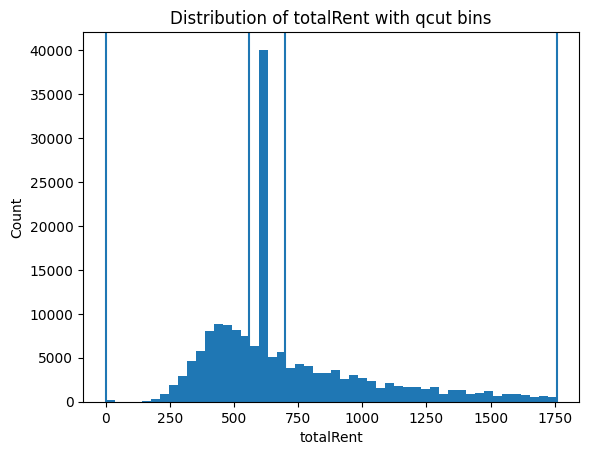

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
_, bins = pd.qcut(train_df['totalRent'], q=3, retbins=True)
print(bins)
print(len(bins))
plt.figure()
plt.hist(train_df['totalRent'], bins=50)
for b in bins:
    plt.axvline(b)

plt.title("Distribution of totalRent with qcut bins")
plt.xlabel("totalRent")
plt.ylabel("Count")
plt.show()

In [4]:
target = "totalRent"

drop_cols = ["totalRent", "baseRent"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]

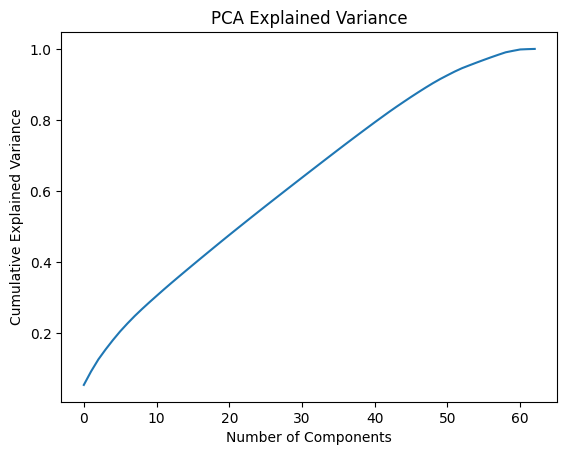

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_scaled)

cumu_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumu_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
model_1 = Pipeline([
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

model_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

model_3 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50)), # 90%
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

model_4 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=55)), # 95%
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

models = {
    "KNN (no scaling)": model_1,
    "KNN + scaling": model_2,
    "KNN + PCA 90%": model_3,
    "KNN + PCA 95% (more components)": model_4
}

# Validation set evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    print(f"{name}: RMSE={rmse:.2f}, R2={r2:.4f}")


KNN (no scaling): RMSE=223.64, R2=0.4797
KNN + scaling: RMSE=222.02, R2=0.4872
KNN + PCA 90%: RMSE=222.91, R2=0.4831
KNN + PCA 95% (more components): RMSE=224.42, R2=0.4761


In [7]:
# Test set evaluation
for name, model in models.items():
    y_test_pred = model.predict(X_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    print(f"{name}: RMSE={rmse_test:.2f}, R2={r2_test:.4f}")

KNN (no scaling): RMSE=225.32, R2=0.4837
KNN + scaling: RMSE=221.53, R2=0.5009
KNN + PCA 90%: RMSE=223.32, R2=0.4928
KNN + PCA 95% (more components): RMSE=223.75, R2=0.4908


In [8]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

from sklearn.metrics import r2_score, root_mean_squared_error

print("RMSE:", root_mean_squared_error(y_val, y_pred))
print("R2:", r2_score(y_val, y_pred))

RMSE: 184.8003255837519
R2: 0.6447504188152938


In [9]:
y_test_pred = rf.predict(X_test)
print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Test RMSE: 184.35305484675095
Test R2: 0.6543486554984708


In [10]:
drop_cols = ["totalRent"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]

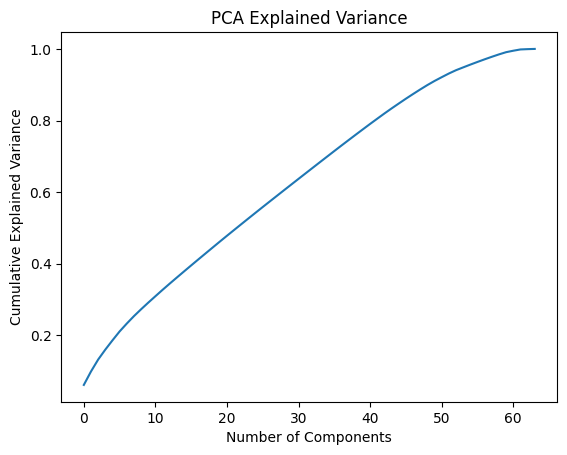

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_scaled)

cumu_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumu_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
model_1 = Pipeline([
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

model_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=9))
])

model_3 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=55)), # 90%
    ("knn", KNeighborsRegressor(n_neighbors=9))
])


models = {
    "KNN (no scaling)": model_1,
    "KNN + scaling": model_2,
    "KNN + PCA 90%": model_3,
}

# Validation set evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    print(f"{name}: RMSE={rmse:.2f}, R2={r2:.4f}")


KNN (no scaling): RMSE=153.29, R2=0.7556
KNN + scaling: RMSE=191.88, R2=0.6170
KNN + PCA 90%: RMSE=208.16, R2=0.5493


In [13]:
# Test set evaluation
for name, model in models.items():
    y_test_pred = model.predict(X_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    print(f"{name}: RMSE={rmse_test:.2f}, R2={r2_test:.4f}")

KNN (no scaling): RMSE=153.02, R2=0.7619
KNN + scaling: RMSE=192.48, R2=0.6232
KNN + PCA 90%: RMSE=207.73, R2=0.5611


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

from sklearn.metrics import r2_score, root_mean_squared_error

print("RMSE:", root_mean_squared_error(y_val, y_pred))
print("R2:", r2_score(y_val, y_pred))

RMSE: 138.30834827926597
R2: 0.8010129102878187


In [15]:
y_test_pred = rf.predict(X_test)
print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Test RMSE: 137.55060050937414
Test R2: 0.8075745304691009


# MULTILAYER PERCEPTION

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# 1. Scale data — quan trọng nhất
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

rg = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    batch_size=256,       
    learning_rate='adaptive',
    max_iter=500,
    early_stopping=True, 
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=42,
    verbose=True          
)

rg.fit(X_train_scaled, y_train)
y_pred = rg.predict(X_val_scaled)

Iteration 1, loss = 84846.74172037
Validation score: 0.677220
Iteration 2, loss = 14264.50416661
Validation score: 0.719311
Iteration 3, loss = 13283.33946675
Validation score: 0.727838
Iteration 4, loss = 12922.45663446
Validation score: 0.733166
Iteration 5, loss = 12694.22233264
Validation score: 0.736857
Iteration 6, loss = 12491.80392935
Validation score: 0.740910
Iteration 7, loss = 12278.00848228
Validation score: 0.744877
Iteration 8, loss = 12092.49156378
Validation score: 0.748379
Iteration 9, loss = 11919.83101810
Validation score: 0.751240
Iteration 10, loss = 11796.10983748
Validation score: 0.753389
Iteration 11, loss = 11684.94907956
Validation score: 0.755402
Iteration 12, loss = 11578.21271563
Validation score: 0.756173
Iteration 13, loss = 11493.41787922
Validation score: 0.757245
Iteration 14, loss = 11422.38074757
Validation score: 0.759216
Iteration 15, loss = 11358.04197273
Validation score: 0.759617
Iteration 16, loss = 11300.26673537
Validation score: 0.761021
I

## Testing

In [17]:
y_test_scaled = scaler.transform(X_test)
y_test_pred = rg.predict(y_test_scaled)
print("Validation RMSE:", root_mean_squared_error(y_val, y_pred))
print("Validation R2:", r2_score(y_val, y_pred))
print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Validation RMSE: 149.29646364931705
Validation R2: 0.7681392949421373
Test RMSE: 149.4881967432262
Test R2: 0.772725150096895


# Light Gradient Boosting Machine

In [21]:
from lightgbm import LGBMRegressor
import lightgbm as lgb

lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,        # Dùng tất cả CPU cores
    verbose=-1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

Training until validation scores don't improve for 50 rounds
[50]	valid_0's l2: 21509.1
[100]	valid_0's l2: 20314.6
[150]	valid_0's l2: 20018.1
[200]	valid_0's l2: 19809.7
[250]	valid_0's l2: 19682.1
[300]	valid_0's l2: 19587
[350]	valid_0's l2: 19493.6
[400]	valid_0's l2: 19420.6
[450]	valid_0's l2: 19340.4
[500]	valid_0's l2: 19301.5
Did not meet early stopping. Best iteration is:
[500]	valid_0's l2: 19301.5


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Testing

In [22]:
y_val_pred = lgbm.predict(X_val)
y_test_pred = lgbm.predict(X_test)
print("Validation RMSE:", root_mean_squared_error(y_val, y_val_pred))
print("Validation R2:", r2_score(y_val, y_val_pred))
print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Validation RMSE: 138.92995732909498
Validation R2: 0.7992202472045057
Test RMSE: 137.62458743208225
Test R2: 0.8073674677992009


# TabNet

In [19]:
# TabNet — pip install pytorch-tabnet
from pytorch_tabnet.tab_model import TabNetRegressor
import numpy as np
import torch

model = TabNetRegressor(
    n_d=32, n_a=32,
    n_steps=5,
    gamma=1.3,
    n_independent=2, n_shared=2,
    optimizer_fn=torch.optim.AdamW,
    optimizer_params=dict(lr=1e-2),
    scheduler_fn=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_params={
        "T_max": 100,  
        "eta_min": 1e-5
    },
    mask_type='entmax',
    device_name='cuda',
    verbose=10,
)
X_train_np = X_train.astype(np.float32).values
X_val_np   = X_val.astype(np.float32).values
y_train_np = y_train.astype(np.float32).values.reshape(-1, 1)
y_val_np   = y_val.astype(np.float32).values.reshape(-1, 1)

model.fit(
    X_train_np, y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    eval_name=['val'],
    eval_metric=['rmse'],
    max_epochs=100,
    patience=10,
    batch_size=256,
)
# Feature importance (tự động!)
feat_imp = model.feature_importances_

d:\ML\AS\.venv\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 94226.82746| val_rmse: 159.56857|  0:01:12s
epoch 10 | loss: 21958.29257| val_rmse: 148.50427|  0:09:04s
epoch 20 | loss: 20330.38625| val_rmse: 151.94166|  0:13:22s

Early stopping occurred at epoch 20 with best_epoch = 10 and best_val_rmse = 148.50427


d:\ML\AS\.venv\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [20]:
from sklearn.metrics import r2_score, root_mean_squared_error
y_pred = model.predict(X_val_np)
print("TabNet RMSE:", root_mean_squared_error(y_val_np, y_pred))
print("TabNet R2:", r2_score(y_val_np, y_pred))

TabNet RMSE: 148.5042724609375
TabNet R2: 0.7705933451652527
